# TP Ingeniería de Datos — Cotizaciones AR



**Cómo presentarlo**

1. Subí **solo este archivo** a [Google Colab](https://colab.research.google.com) (*Archivo → Subir notebook*).
2. Menú **Entorno de ejecución → Ejecutar todas**.
3. Recorre las celdas: API → Bronze → Silver → Gold → gráficos → tiempo real.

Fuente: [DolarAPI](https://dolarapi.com/docs/) (`/v1/dolares` y `/v1/cotizaciones`).


## 0. Entorno

Instala dependencias y deja listo el data lake (en Colab usa `/content`).


In [ ]:
import subprocess
import sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "pandas", "pyarrow", "requests", "matplotlib"]
)

from __future__ import annotations

import hashlib
import json
import logging
import time
import uuid
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import requests

IN_COLAB = "google.colab" in sys.modules
LAKE_ROOT = Path("/content/tp_lake") if IN_COLAB else Path.cwd().resolve().parent.joinpath("data", "lake_colab")
if Path.cwd().name != "notebooks" and not IN_COLAB:
    LAKE_ROOT = Path.cwd().resolve() / "data" / "lake_colab"
LAKE_ROOT.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
logger = logging.getLogger("tp")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams.update({"figure.figsize": (10, 4.8), "axes.titlesize": 13})

print("Colab:" if IN_COLAB else "Local:", "lake =", LAKE_ROOT)


Local: lake = C:\Users\gonzi\TP.ingdatos\data\lake_colab


## 1. Arquitectura medallion

| Capa | Qué guarda | Particionado | Duplicados |
| --- | --- | --- | --- |
| **Bronze** | JSON crudo + metadatos de ingestión | `year/month/day/source` | Append-only (bitácora) |
| **Silver** | Hechos limpios y tipados | `year/month/casa` | Upsert por `business_key` + hash |
| **Gold** | Tablas analíticas | una carpeta por modelo | Se regeneran desde Silver |


## 2. Cliente de DolarAPI

Se unifican dos endpoints y cada registro se etiqueta con `source`, igual que el script de plataformas etiquetaba `platform_name`.


In [ ]:
API_BASE = "https://dolarapi.com"
API_SOURCES = (
    ("dolares", "/v1/dolares"),
    ("cotizaciones", "/v1/cotizaciones"),
)


@dataclass(frozen=True)
class RawQuote:
    source: str
    endpoint: str
    payload: dict[str, Any]


class DolarApiClient:
    """Cliente HTTP con timeout y reintentos."""

    def __init__(self, timeout: int = 15, max_retries: int = 3) -> None:
        self.timeout = timeout
        self.max_retries = max_retries
        self.session = requests.Session()
        self.session.headers.update({"Accept": "application/json", "User-Agent": "tp-ingdatos/1.0"})

    def fetch_endpoint(self, path: str) -> list[dict[str, Any]]:
        url = f"{API_BASE}{path}"
        last_error: Exception | None = None
        for attempt in range(1, self.max_retries + 1):
            try:
                response = self.session.get(url, timeout=self.timeout)
                response.raise_for_status()
                payload = response.json()
                if isinstance(payload, list):
                    return [item for item in payload if isinstance(item, dict)]
                if isinstance(payload, dict):
                    return [payload]
                raise ValueError(f"Respuesta inesperada: {type(payload)}")
            except (requests.RequestException, ValueError) as exc:
                last_error = exc
                time.sleep(2 ** (attempt - 1))
        raise RuntimeError(f"No se pudo obtener {url}") from last_error

    def fetch_all(self) -> list[RawQuote]:
        quotes: list[RawQuote] = []
        for source, path in API_SOURCES:
            records = self.fetch_endpoint(path)
            logger.info("Fuente %s: %s registros", source, len(records))
            quotes.extend(RawQuote(source, path, record) for record in records)
        return quotes


client = DolarApiClient()
raw_quotes = client.fetch_all()
pd.DataFrame([{"source": q.source, **q.payload} for q in raw_quotes])


19:26:49 | INFO     | Fuente dolares: 7 registros


19:26:49 | INFO     | Fuente cotizaciones: 5 registros


,source,moneda,casa,nombre,compra,venta,fechaActualizacion
0,dolares,USD,oficial,Oficial,1480.0000,1530.0000,2026-09-04T18:55:00.000Z
1,dolares,USD,blue,Blue,1520.0000,1540.0000,2026-09-05T20:56:00.000Z
2,dolares,USD,bolsa,Bolsa,1516.9000,1525.3000,2026-09-05T20:56:00.000Z
3,dolares,USD,contadoconliqui,Contado con liquidación,1582.0000,1583.2000,2026-09-05T20:56:00.000Z
4,dolares,USD,mayorista,Mayorista,1499.0000,1508.0000,2026-09-04T16:48:00.000Z
5,dolares,USD,cripto,Cripto,1572.2400,1575.1500,2026-09-05T20:56:00.000Z
6,dolares,USD,tarjeta,Tarjeta,1924.0000,1989.0000,2026-09-04T18:55:00.000Z
7,cotizaciones,USD,oficial,Dólar,1480.0000,1530.0000,2026-09-04T16:57:00.000Z
8,cotizaciones,EUR,oficial,Euro,1739.1398,1753.3516,2026-09-04T16:57:00.000Z
9,cotizaciones,BRL,oficial,Real Brasileño,296.7322,296.9052,2026-09-04T16:58:00.000Z


## 3. Bronze — crudo y auditable

No se limpian campos de negocio. Se guarda el JSON original para poder reprocesar Silver.


In [ ]:
def hash_payload(payload: dict[str, Any] | str) -> str:
    text = json.dumps(payload, sort_keys=True, ensure_ascii=False) if isinstance(payload, dict) else payload
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def build_bronze_frame(quotes: list[RawQuote], ingest_id: str | None = None) -> pd.DataFrame:
    ingest_ts = datetime.now(timezone.utc)
    ingest_id = ingest_id or str(uuid.uuid4())
    rows = [
        {
            "ingest_id": ingest_id,
            "ingest_ts": ingest_ts.isoformat(),
            "source": quote.source,
            "endpoint": quote.endpoint,
            "payload_json": json.dumps(quote.payload, ensure_ascii=False),
            "record_hash": hash_payload(quote.payload),
            "year": ingest_ts.year,
            "month": ingest_ts.month,
            "day": ingest_ts.day,
        }
        for quote in quotes
    ]
    return pd.DataFrame(rows)


bronze_df = build_bronze_frame(raw_quotes)
print(f"Bronze en memoria: {len(bronze_df)} filas | fuentes={sorted(bronze_df['source'].unique())}")
bronze_df.head(3)


Bronze en memoria: 12 filas | fuentes=['cotizaciones', 'dolares']


,ingest_id,ingest_ts,source,endpoint,payload_json,record_hash,year,month,day
0,b055241f-0221-40b8-b90e-6a050b87df97,2026-09-05T22:26:49.659208+00:00,dolares,/v1/dolares,"{""moneda"": ""USD"", ""casa"": ""oficial"", ""nombre"":...",5cc1f60d640d1d9bc745fb5186742c6fc46bc3eaff663a...,2026,9,5
1,b055241f-0221-40b8-b90e-6a050b87df97,2026-09-05T22:26:49.659208+00:00,dolares,/v1/dolares,"{""moneda"": ""USD"", ""casa"": ""blue"", ""nombre"": ""B...",3bd6d3a5d177e339070f8cd6d844c89c60272d7b82f3cb...,2026,9,5
2,b055241f-0221-40b8-b90e-6a050b87df97,2026-09-05T22:26:49.659208+00:00,dolares,/v1/dolares,"{""moneda"": ""USD"", ""casa"": ""bolsa"", ""nombre"": ""...",66720d05ae2152c8ff4468d91eb0b7adb33d9d753b0179...,2026,9,5


## 4. Utilidades de transformación

`fill_null_values` y `explode_column` son las mismas ideas del script de plataformas, generalizadas.


In [ ]:
def fill_null_values(df: pd.DataFrame, column_name: str, fill_value: Any) -> pd.DataFrame:
    """Rellena nulos de una columna con un valor explícito."""
    if column_name not in df.columns:
        return df
    df[column_name] = df[column_name].fillna(fill_value)
    return df


def explode_column(
    df_origin: pd.DataFrame,
    cols_to_select: list[str],
    col_to_explode: str,
    delimiter: str = ",",
) -> pd.DataFrame:
    """Expande valores separados por comas a una fila por valor."""
    result = df_origin.loc[:, cols_to_select].copy()
    result[col_to_explode] = result[col_to_explode].fillna("").astype(str).str.split(delimiter)
    result = result.explode(col_to_explode, ignore_index=True)
    result[col_to_explode] = result[col_to_explode].str.strip()
    return result[result[col_to_explode] != ""].reset_index(drop=True)


demo = pd.DataFrame({"casa": ["oficial"], "market_tags": ["regulado, banco, bcra"]})
explode_column(demo, ["casa", "market_tags"], "market_tags")


,casa,market_tags
0,oficial,regulado
1,oficial,banco
2,oficial,bcra


## 5. Silver — más de cuatro transformaciones

Orden vectorizado:

1. Parseo del JSON  
2. Normalización de esquema  
3. Imputación de nulos  
4. Casteo de tipos  
5. Columnas de partición  
6. Tags de mercado  
7. Spread / mid / spread %  
8. Reglas de calidad (se marcan, no se borran)  
9. Clave de negocio + hash  
10. Deduplicación


In [ ]:
MARKET_TAGS = {
    "oficial": "regulado,banco,bcra",
    "blue": "paralelo,informal",
    "bolsa": "financiero,merval,mep",
    "contadoconliqui": "financiero,ccl,bursatil",
    "mayorista": "regulado,interbancario",
    "cripto": "digital,crypto",
    "tarjeta": "regulado,impuesto,turismo",
}
SILVER_COLS = [
    "ingest_id", "ingest_ts", "source", "endpoint", "moneda", "casa", "nombre",
    "compra", "venta", "fecha_actualizacion", "fecha_actualizacion_iso", "market_tags",
    "spread", "mid_price", "spread_pct", "quality_ok", "quality_flags",
    "business_key", "record_hash", "year", "month", "day",
]


def parse_bronze_payload(bronze: pd.DataFrame) -> pd.DataFrame:
    parsed = pd.json_normalize(bronze["payload_json"].map(json.loads).tolist())
    return pd.concat([bronze[["ingest_id", "ingest_ts", "source", "endpoint"]].reset_index(drop=True), parsed], axis=1)


def normalize_schema(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={"fechaActualizacion": "fecha_actualizacion"})
    for column in ("moneda", "casa", "nombre", "compra", "venta", "fecha_actualizacion"):
        if column not in df.columns:
            df[column] = pd.NA
    df["moneda"] = df["moneda"].astype("string").str.strip().str.upper()
    df["casa"] = df["casa"].astype("string").str.strip().str.lower()
    df["nombre"] = df["nombre"].astype("string").str.strip().str.title()
    return df


def fill_missing_attributes(df: pd.DataFrame) -> pd.DataFrame:
    for column, value in {"casa": "desconocida", "nombre": "N/A", "moneda": "N/A"}.items():
        df = fill_null_values(df, column, value)
    return df


def cast_types(df: pd.DataFrame) -> pd.DataFrame:
    df["compra"] = pd.to_numeric(df["compra"], errors="coerce")
    df["venta"] = pd.to_numeric(df["venta"], errors="coerce")
    df["fecha_actualizacion"] = pd.to_datetime(df["fecha_actualizacion"], utc=True, errors="coerce")
    df["ingest_ts"] = pd.to_datetime(df["ingest_ts"], utc=True, errors="coerce")
    df.loc[df["fecha_actualizacion"].isna(), "fecha_actualizacion"] = pd.Timestamp("1900-01-01", tz="UTC")
    df["fecha_actualizacion_iso"] = df["fecha_actualizacion"].dt.strftime("%Y-%m-%d %H:%M:%S")
    return df


def add_partition_columns(df: pd.DataFrame) -> pd.DataFrame:
    df["year"] = df["fecha_actualizacion"].dt.year.astype("int32")
    df["month"] = df["fecha_actualizacion"].dt.month.astype("int32")
    df["day"] = df["fecha_actualizacion"].dt.day.astype("int32")
    return df


def assign_market_tags(df: pd.DataFrame) -> pd.DataFrame:
    df["market_tags"] = df["casa"].map(MARKET_TAGS).fillna("otro")
    return df


def compute_price_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df["spread"] = df["venta"] - df["compra"]
    df["mid_price"] = (df["venta"] + df["compra"]) / 2.0
    df["spread_pct"] = (df["spread"] / df["compra"]) * 100.0
    df.loc[df["compra"].fillna(0) <= 0, "spread_pct"] = pd.NA
    return df


def apply_quality_rules(df: pd.DataFrame) -> pd.DataFrame:
    flags = {
        "precio_nulo": df["compra"].isna() | df["venta"].isna(),
        "compra_negativa": df["compra"].fillna(-1) < 0,
        "venta_negativa": df["venta"].fillna(-1) < 0,
        "venta_menor_compra": df["venta"] < df["compra"],
        "fecha_default": df["fecha_actualizacion"] == pd.Timestamp("1900-01-01", tz="UTC"),
    }
    df["quality_ok"] = ~pd.DataFrame(flags).any(axis=1)
    df["quality_flags"] = ""
    for name, mask in flags.items():
        df.loc[mask, "quality_flags"] = df.loc[mask, "quality_flags"] + name + ","
    df["quality_flags"] = df["quality_flags"].str.rstrip(",")
    return df


def add_identity_keys(df: pd.DataFrame) -> pd.DataFrame:
    df["business_key"] = (
        df["source"].astype(str) + "|" + df["casa"].astype(str) + "|"
        + df["moneda"].astype(str) + "|" + df["fecha_actualizacion"].astype(str)
    )
    content = (
        df["source"].astype(str) + "|" + df["casa"].astype(str) + "|" + df["moneda"].astype(str)
        + "|" + df["compra"].astype(str) + "|" + df["venta"].astype(str)
        + "|" + df["fecha_actualizacion"].astype(str)
    )
    df["record_hash"] = content.map(lambda value: hashlib.sha256(value.encode("utf-8")).hexdigest())
    return df


def deduplicate_quotes(df: pd.DataFrame) -> pd.DataFrame:
    """Una fila vigente por clave de negocio; gana la ingestión más reciente."""
    if df.empty:
        return df
    ordered = df.sort_values(["business_key", "ingest_ts"], ascending=[True, False], kind="mergesort")
    deduped = ordered.drop_duplicates(subset=["business_key"], keep="first")
    removed = len(df) - len(deduped)
    if removed:
        logger.info("Deduplicación: se removieron %s filas repetidas", removed)
    return deduped.reset_index(drop=True)


def bronze_to_silver(bronze: pd.DataFrame) -> pd.DataFrame:
    df = parse_bronze_payload(bronze)
    df = normalize_schema(df)
    df = fill_missing_attributes(df)
    df = cast_types(df)
    df = add_partition_columns(df)
    df = assign_market_tags(df)
    df = compute_price_metrics(df)
    df = apply_quality_rules(df)
    df = add_identity_keys(df)
    df = deduplicate_quotes(df)
    return df.loc[:, SILVER_COLS]


silver_once = bronze_to_silver(bronze_df)
duplicated = pd.concat([silver_once, silver_once], ignore_index=True)
silver_df = deduplicate_quotes(duplicated)
print(f"Antes de dedup: {len(duplicated)} | después: {len(silver_df)} | quality_ok: {int(silver_df['quality_ok'].sum())}")
silver_df[["source", "casa", "moneda", "compra", "venta", "spread", "spread_pct", "quality_ok"]].sort_values(["moneda", "casa"])


19:26:50 | INFO     | Deduplicación: se removieron 12 filas repetidas


Antes de dedup: 24 | después: 12 | quality_ok: 12


,source,casa,moneda,compra,venta,spread,spread_pct,quality_ok
0,cotizaciones,oficial,BRL,296.7322,296.9052,0.1730,0.058302,True
1,cotizaciones,oficial,CLP,1.6142,1.6142,0.0000,0.000000,True
2,cotizaciones,oficial,EUR,1739.1398,1753.3516,14.2118,0.817174,True
5,dolares,blue,USD,1520.0000,1540.0000,20.0000,1.315789,True
6,dolares,bolsa,USD,1516.9000,1525.3000,8.4000,0.553761,True
7,dolares,contadoconliqui,USD,1582.0000,1583.2000,1.2000,0.075853,True
8,dolares,cripto,USD,1572.2400,1575.1500,2.9100,0.185086,True
9,dolares,mayorista,USD,1499.0000,1508.0000,9.0000,0.600400,True
3,cotizaciones,oficial,USD,1480.0000,1530.0000,50.0000,3.378378,True
10,dolares,oficial,USD,1480.0000,1530.0000,50.0000,3.378378,True


## 6. Persistencia Parquet + particionado

Bronze es append-only. Silver se fusiona y se reescribe sin claves repetidas.


In [ ]:
def write_partitioned(frame: pd.DataFrame, path: Path, partition_cols: list[str], basename: str) -> None:
    path.mkdir(parents=True, exist_ok=True)
    table = pa.Table.from_pandas(frame, preserve_index=False)
    partitioning = ds.partitioning(
        pa.schema([(col, table.schema.field(col).type) for col in partition_cols]),
        flavor="hive",
    )
    ds.write_dataset(
        table,
        path,
        format="parquet",
        partitioning=partitioning,
        existing_data_behavior="overwrite_or_ignore",
        basename_template=basename,
    )


def remove_tree(path: Path) -> None:
    if not path.exists():
        return
    for child in path.rglob("*"):
        if child.is_file():
            child.unlink()
    for child in sorted(path.rglob("*"), reverse=True):
        if child.is_dir():
            child.rmdir()
    if path.exists():
        path.rmdir()


def read_partitioned(path: Path) -> pd.DataFrame:
    if not path.exists() or not any(path.rglob("*.parquet")):
        return pd.DataFrame()
    return ds.dataset(path, format="parquet", partitioning="hive").to_table().to_pandas()


bronze_path = LAKE_ROOT / "bronze" / "quotes"
silver_path = LAKE_ROOT / "silver" / "quotes"
gold_path = LAKE_ROOT / "gold"

write_partitioned(bronze_df, bronze_path, ["year", "month", "day", "source"], f"{uuid.uuid4().hex}-{{i}}.parquet")

existing_silver = read_partitioned(silver_path)
combined_silver = silver_df if existing_silver.empty else pd.concat([existing_silver, silver_df], ignore_index=True)
combined_silver = deduplicate_quotes(combined_silver)
remove_tree(silver_path)
write_partitioned(combined_silver, silver_path, ["year", "month", "casa"], "part-{i}.parquet")
silver_df = combined_silver

print("Particiones Bronze:")
for path in sorted(bronze_path.rglob("*.parquet"))[:6]:
    print(" ", path.relative_to(LAKE_ROOT))
print("\nParticiones Silver:")
for path in sorted(silver_path.rglob("casa=*")):
    print(" ", path.relative_to(LAKE_ROOT))
print(f"\nLake: Bronze={len(read_partitioned(bronze_path))} | Silver={len(silver_df)}")


Particiones Bronze:
  bronze\quotes\year=2026\month=9\day=5\source=cotizaciones\5d6545e934754d5bb989b8c66543e9e6-0.parquet
  bronze\quotes\year=2026\month=9\day=5\source=dolares\5d6545e934754d5bb989b8c66543e9e6-0.parquet

Particiones Silver:
  silver\quotes\year=2026\month=9\casa=blue
  silver\quotes\year=2026\month=9\casa=bolsa
  silver\quotes\year=2026\month=9\casa=contadoconliqui
  silver\quotes\year=2026\month=9\casa=cripto
  silver\quotes\year=2026\month=9\casa=mayorista
  silver\quotes\year=2026\month=9\casa=oficial
  silver\quotes\year=2026\month=9\casa=tarjeta

Lake: Bronze=12 | Silver=12


## 7. Gold — modelos analíticos

Transformaciones extra: filtro de calidad, unpivot, explode de tags, variación, join as-of vs oficial y agregados diarios.


In [ ]:
def filter_valid_quotes(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[df["quality_ok"]].copy() if not df.empty else df


def unpivot_prices(df: pd.DataFrame) -> pd.DataFrame:
    return pd.melt(
        df,
        id_vars=["source", "casa", "nombre", "moneda", "fecha_actualizacion", "business_key", "year", "month", "day"],
        value_vars=["compra", "venta"],
        var_name="tipo_precio",
        value_name="precio",
    )


def explode_market_tags(df: pd.DataFrame) -> pd.DataFrame:
    return explode_column(
        df, ["business_key", "source", "casa", "moneda", "fecha_actualizacion", "market_tags"], "market_tags"
    )


def compute_variations(df: pd.DataFrame) -> pd.DataFrame:
    ordered = df.sort_values(["casa", "moneda", "fecha_actualizacion", "ingest_ts"], kind="mergesort")
    ordered["venta_anterior"] = ordered.groupby(["casa", "moneda"], sort=False)["venta"].shift(1)
    ordered["var_venta_pct"] = ((ordered["venta"] - ordered["venta_anterior"]) / ordered["venta_anterior"]) * 100.0
    return ordered


def join_oficial_reference(df: pd.DataFrame) -> pd.DataFrame:
    oficial = (
        df.loc[(df["casa"] == "oficial") & (df["moneda"] == "USD") & (df["source"] == "dolares")]
        .sort_values("fecha_actualizacion")
        .loc[:, ["fecha_actualizacion", "venta", "compra"]]
        .rename(columns={"venta": "venta_oficial", "compra": "compra_oficial"})
    )
    if oficial.empty:
        result = df.copy()
        result["venta_oficial"] = pd.NA
        result["brecha_oficial_pct"] = pd.NA
        return result
    merged = pd.merge_asof(df.sort_values("fecha_actualizacion"), oficial, on="fecha_actualizacion", direction="backward")
    merged["brecha_oficial_pct"] = pd.Series(pd.NA, index=merged.index, dtype="Float64")
    usd = merged["moneda"] == "USD"
    merged.loc[usd, "brecha_oficial_pct"] = (
        (merged.loc[usd, "venta"] - merged.loc[usd, "venta_oficial"]) / merged.loc[usd, "venta_oficial"]
    ) * 100.0
    return merged


def build_latest_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    usd = df.loc[(df["moneda"] == "USD") & (df["source"] == "dolares")]
    others = df.loc[df["moneda"] != "USD"]
    combined = pd.concat([usd, others], ignore_index=True)
    combined = combined.sort_values(
        ["casa", "moneda", "fecha_actualizacion", "ingest_ts"],
        ascending=[True, True, False, False],
        kind="mergesort",
    )
    return combined.drop_duplicates(subset=["casa", "moneda"], keep="first").reset_index(drop=True)


def aggregate_daily_metrics(df: pd.DataFrame) -> pd.DataFrame:
    daily = df.groupby(["year", "month", "day", "casa", "moneda", "source"], as_index=False).agg(
        cotizaciones=("venta", "size"),
        venta_min=("venta", "min"),
        venta_max=("venta", "max"),
        venta_promedio=("venta", "mean"),
        spread_promedio=("spread", "mean"),
    )
    daily["rango_venta"] = daily["venta_max"] - daily["venta_min"]
    return daily


def build_fx_cross(latest: pd.DataFrame) -> pd.DataFrame:
    usd = latest.loc[(latest["moneda"] == "USD") & (latest["casa"] == "oficial")]
    if usd.empty:
        return pd.DataFrame()
    usd_venta = float(usd.iloc[0]["venta"])
    fx = latest.loc[(latest["casa"] == "oficial") & (latest["moneda"] != "USD")].copy()
    fx["usd_oficial_venta"] = usd_venta
    fx["unidades_por_usd"] = fx["venta"] / usd_venta
    return fx.rename(columns={"venta": "venta_ars"})[
        ["moneda", "nombre", "venta_ars", "usd_oficial_venta", "unidades_por_usd", "fecha_actualizacion"]
    ]


def build_gold_tables(silver: pd.DataFrame) -> dict[str, pd.DataFrame]:
    valid = filter_valid_quotes(silver)
    with_ref = join_oficial_reference(valid)
    variations = compute_variations(with_ref)
    latest = build_latest_snapshot(variations)
    return {
        "latest": latest,
        "daily_metrics": aggregate_daily_metrics(variations),
        "brecha": latest[
            ["casa", "nombre", "moneda", "venta", "venta_oficial", "brecha_oficial_pct", "spread", "spread_pct", "fecha_actualizacion"]
        ].sort_values("brecha_oficial_pct", na_position="last"),
        "prices_long": unpivot_prices(latest),
        "market_tags": explode_market_tags(latest),
        "fx_cross": build_fx_cross(latest),
        "variations": variations[
            ["casa", "moneda", "fecha_actualizacion", "venta", "venta_anterior", "var_venta_pct", "brecha_oficial_pct"]
        ],
    }


gold = build_gold_tables(silver_df)
remove_tree(gold_path)
gold_path.mkdir(parents=True, exist_ok=True)
for name, frame in gold.items():
    target = gold_path / name
    target.mkdir(parents=True, exist_ok=True)
    if not frame.empty:
        frame.to_parquet(target / "data.parquet", index=False)

pd.DataFrame({"tabla": list(gold), "filas": [len(frame) for frame in gold.values()]})


,tabla,filas
0,latest,11
1,daily_metrics,12
2,brecha,11
3,prices_long,22
4,market_tags,30
5,fx_cross,4
6,variations,12


In [ ]:
latest = gold["latest"]
latest[["casa", "nombre", "moneda", "compra", "venta", "spread", "spread_pct", "brecha_oficial_pct"]]


,casa,nombre,moneda,compra,venta,spread,spread_pct,brecha_oficial_pct
0,blue,Blue,USD,1520.0000,1540.0000,20.0000,1.315789,0.653595
1,bolsa,Bolsa,USD,1516.9000,1525.3000,8.4000,0.553761,-0.30719
2,contadoconliqui,Contado Con Liquidación,USD,1582.0000,1583.2000,1.2000,0.075853,3.477124
3,cripto,Cripto,USD,1572.2400,1575.1500,2.9100,0.185086,2.95098
4,mayorista,Mayorista,USD,1499.0000,1508.0000,9.0000,0.600400,<NA>
5,oficial,Real Brasileño,BRL,296.7322,296.9052,0.1730,0.058302,<NA>
6,oficial,Peso Chileno,CLP,1.6142,1.6142,0.0000,0.000000,<NA>
7,oficial,Euro,EUR,1739.1398,1753.3516,14.2118,0.817174,<NA>
8,oficial,Oficial,USD,1480.0000,1530.0000,50.0000,3.378378,0.0
9,oficial,Peso Uruguayo,UYU,37.4453,37.4455,0.0002,0.000534,<NA>


## 8. Visualizaciones (capa Gold)


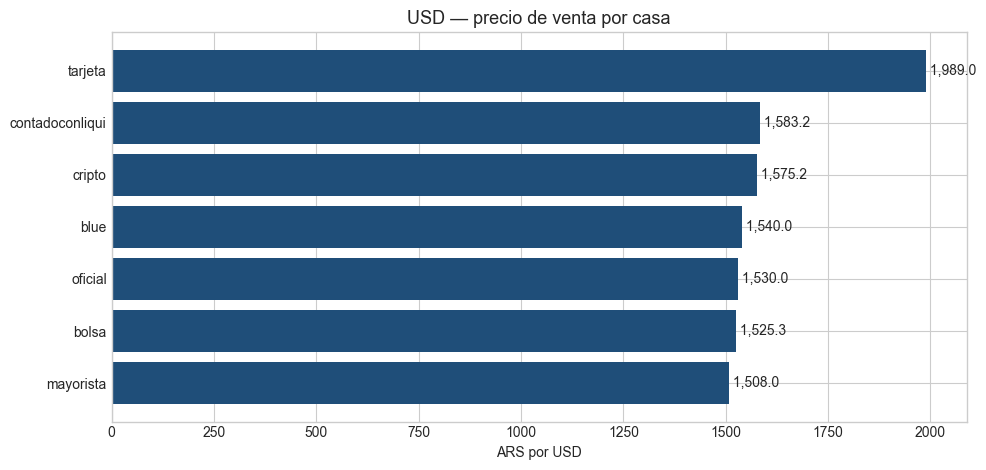

In [ ]:
usd = latest.loc[latest["moneda"] == "USD"].sort_values("venta")

fig, ax = plt.subplots()
ax.barh(usd["casa"], usd["venta"], color="#1f4e79")
ax.set_title("USD — precio de venta por casa")
ax.set_xlabel("ARS por USD")
for value, name in zip(usd["venta"], usd["casa"]):
    ax.text(value, name, f" {value:,.1f}", va="center")
plt.tight_layout()
plt.show()


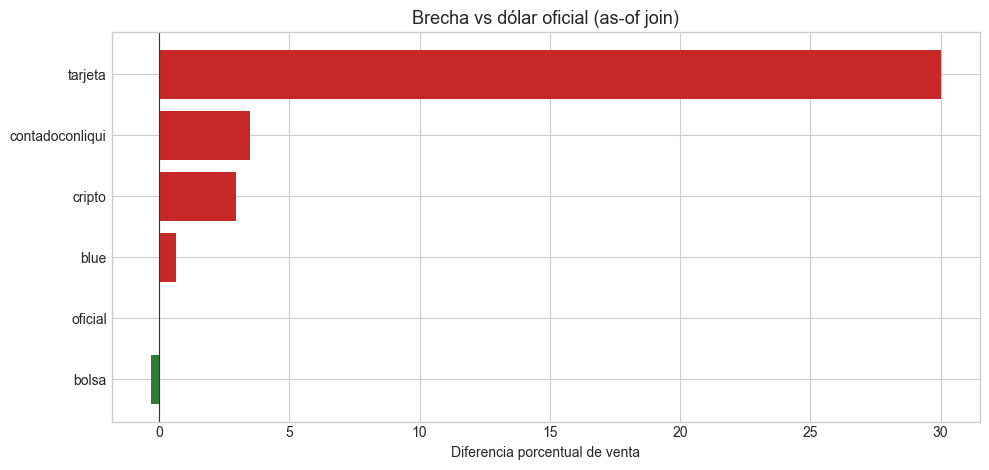

In [ ]:
brecha = usd.dropna(subset=["brecha_oficial_pct"]).sort_values("brecha_oficial_pct")
colors = ["#2e7d32" if value <= 0 else "#c62828" for value in brecha["brecha_oficial_pct"]]

fig, ax = plt.subplots()
ax.barh(brecha["casa"], brecha["brecha_oficial_pct"], color=colors)
ax.axvline(0, color="#333", linewidth=0.8)
ax.set_title("Brecha vs dólar oficial (as-of join)")
ax.set_xlabel("Diferencia porcentual de venta")
plt.tight_layout()
plt.show()


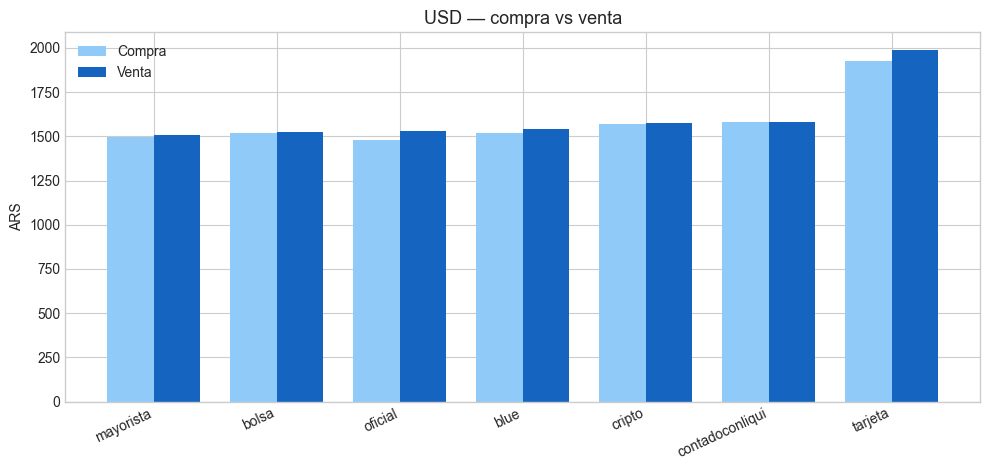

,casa,compra,venta,spread,spread_pct
0,mayorista,1499.00,1508.00,9.00,0.600400
1,bolsa,1516.90,1525.30,8.40,0.553761
2,oficial,1480.00,1530.00,50.00,3.378378
3,blue,1520.00,1540.00,20.00,1.315789
4,cripto,1572.24,1575.15,2.91,0.185086
5,contadoconliqui,1582.00,1583.20,1.20,0.075853
6,tarjeta,1924.00,1989.00,65.00,3.378378


In [ ]:
fig, ax = plt.subplots()
idx = range(len(usd))
width = 0.38
ax.bar([i - width / 2 for i in idx], usd["compra"], width=width, label="Compra", color="#90caf9")
ax.bar([i + width / 2 for i in idx], usd["venta"], width=width, label="Venta", color="#1565c0")
ax.set_xticks(list(idx))
ax.set_xticklabels(usd["casa"], rotation=25, ha="right")
ax.set_title("USD — compra vs venta")
ax.set_ylabel("ARS")
ax.legend()
plt.tight_layout()
plt.show()
usd[["casa", "compra", "venta", "spread", "spread_pct"]].reset_index(drop=True)


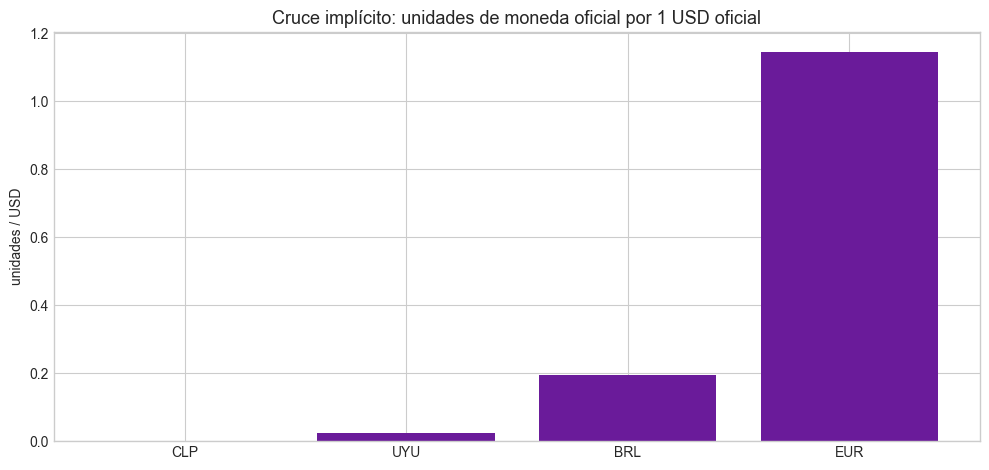

,moneda,nombre,venta_ars,usd_oficial_venta,unidades_por_usd,fecha_actualizacion
6,CLP,Peso Chileno,1.6142,1530.0,0.001055,2026-09-04 16:58:00+00:00
9,UYU,Peso Uruguayo,37.4455,1530.0,0.024474,2026-09-04 16:58:00+00:00
5,BRL,Real Brasileño,296.9052,1530.0,0.194056,2026-09-04 16:58:00+00:00
7,EUR,Euro,1753.3516,1530.0,1.145981,2026-09-04 16:57:00+00:00


In [ ]:
fx = gold["fx_cross"].sort_values("unidades_por_usd")
fig, ax = plt.subplots()
ax.bar(fx["moneda"], fx["unidades_por_usd"], color="#6a1b9a")
ax.set_title("Cruce implícito: unidades de moneda oficial por 1 USD oficial")
ax.set_ylabel("unidades / USD")
plt.tight_layout()
plt.show()
fx


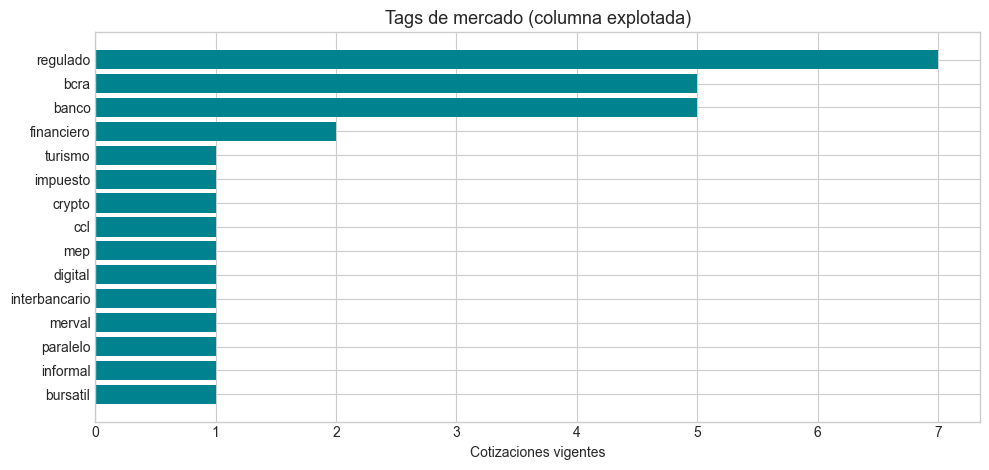

,business_key,source,casa,moneda,fecha_actualizacion,market_tags
0,dolares|blue|USD|2026-09-05 20:56:00+00:00,dolares,blue,USD,2026-09-05 20:56:00+00:00,paralelo
1,dolares|blue|USD|2026-09-05 20:56:00+00:00,dolares,blue,USD,2026-09-05 20:56:00+00:00,informal
2,dolares|bolsa|USD|2026-09-05 20:56:00+00:00,dolares,bolsa,USD,2026-09-05 20:56:00+00:00,financiero
3,dolares|bolsa|USD|2026-09-05 20:56:00+00:00,dolares,bolsa,USD,2026-09-05 20:56:00+00:00,merval
4,dolares|bolsa|USD|2026-09-05 20:56:00+00:00,dolares,bolsa,USD,2026-09-05 20:56:00+00:00,mep
5,dolares|contadoconliqui|USD|2026-09-05 20:56:0...,dolares,contadoconliqui,USD,2026-09-05 20:56:00+00:00,financiero
6,dolares|contadoconliqui|USD|2026-09-05 20:56:0...,dolares,contadoconliqui,USD,2026-09-05 20:56:00+00:00,ccl
7,dolares|contadoconliqui|USD|2026-09-05 20:56:0...,dolares,contadoconliqui,USD,2026-09-05 20:56:00+00:00,bursatil


In [ ]:
tags = gold["market_tags"]["market_tags"].value_counts().sort_values()
fig, ax = plt.subplots()
ax.barh(tags.index, tags.values, color="#00838f")
ax.set_title("Tags de mercado (columna explotada)")
ax.set_xlabel("Cotizaciones vigentes")
plt.tight_layout()
plt.show()
gold["market_tags"].head(8)


## 9. Tiempo real (micro-lotes)

DolarAPI es REST: un productor consulta dos veces y el consumidor solo promueve a Silver si el hash es nuevo.


In [ ]:
known_hashes = set(silver_df["record_hash"].tolist())
print("Hashes Silver vigentes:", len(known_hashes))

for cycle in range(1, 3):
    logger.info("Micro-lote %s: consultando API...", cycle)
    batch = client.fetch_all()
    bronze_batch = build_bronze_frame(batch)
    write_partitioned(
        bronze_batch, bronze_path, ["year", "month", "day", "source"], f"{uuid.uuid4().hex}-{{i}}.parquet"
    )
    silver_batch = bronze_to_silver(bronze_batch)
    new_rows = silver_batch.loc[~silver_batch["record_hash"].isin(known_hashes)]
    if new_rows.empty:
        logger.info("Micro-lote %s: sin cambios de cotización; Silver no se reescribe", cycle)
    else:
        silver_df = deduplicate_quotes(pd.concat([silver_df, new_rows], ignore_index=True))
        known_hashes.update(new_rows["record_hash"].tolist())
        remove_tree(silver_path)
        write_partitioned(silver_df, silver_path, ["year", "month", "casa"], "part-{i}.parquet")
        gold = build_gold_tables(silver_df)
        logger.info("Micro-lote %s: %s cotizaciones nuevas", cycle, len(new_rows))
    if cycle < 2:
        time.sleep(3)

bronze_all = read_partitioned(bronze_path)
pd.DataFrame(
    {
        "capa": ["bronze", "silver"],
        "filas": [len(bronze_all), len(silver_df)],
        "detalle": ["histórico append-only", "hechos únicos vigentes"],
    }
)


19:26:53 | INFO     | Micro-lote 1: consultando API...


19:26:53 | INFO     | Fuente dolares: 7 registros


19:26:53 | INFO     | Fuente cotizaciones: 5 registros


Hashes Silver vigentes: 12


19:26:54 | INFO     | Micro-lote 1: sin cambios de cotización; Silver no se reescribe


19:26:57 | INFO     | Micro-lote 2: consultando API...


19:26:57 | INFO     | Fuente dolares: 7 registros


19:26:57 | INFO     | Fuente cotizaciones: 5 registros


19:26:57 | INFO     | Micro-lote 2: sin cambios de cotización; Silver no se reescribe


,capa,filas,detalle
0,bronze,36,histórico append-only
1,silver,12,hechos únicos vigentes


## 10. Cierre — cómo cubre la consigna

1. **Más de cuatro transformaciones**: parseo, normalización, nulos, tipos, particiones, tags, métricas, calidad, identidad, dedup, unpivot, explode, variación, join as-of y agregación diaria.
2. **Guardado eficiente y sin repetidos**: Parquet + particiones Hive. Bronze crece; Silver no repite `business_key`.
3. **Código modular y documentado**: cada transformación es una función con docstring; el notebook se recorre en orden.
4. **Ejecución simple y performante**: pandas vectorizado, un *Ejecutar todas* en Colab.

API: [dolarapi.com/docs](https://dolarapi.com/docs/).
